In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [5]:
print("Missing values")
df.isnull().sum()

Missing values


Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

since no missing. therefore no imputation techniques are required

In [6]:
df["Weather_Conditions"].unique()

<ArrowStringArray>
['Rainy', 'Cloudy', 'Snowy', 'Sunny']
Length: 4, dtype: str

In [7]:
df["Traffic_Conditions"].unique()

<ArrowStringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str

One-Hot Encoding

In [10]:
df = pd.get_dummies(df, columns=['Weather_Conditions', "Traffic_Conditions"])
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Traffic_Conditions_High,Traffic_Conditions_Low,Traffic_Conditions_Medium
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54,False,True,False,False,False,False,True
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02,True,False,False,False,False,False,True
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17,False,False,True,False,False,False,True
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23,True,False,False,False,False,True,False
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34,False,True,False,False,True,False,False


In [11]:
from sklearn.preprocessing import MinMaxScaler
minmaxscaler = MinMaxScaler()

In [12]:
df[["Distance", "Delivery_Time"]] = minmaxscaler.fit_transform(
    df[["Distance", "Delivery_Time"]]
)

In [13]:
df[["Distance", "Delivery_Time"]].head(15)

,Distance,Delivery_Time
0,0.043068,0.105228
1,0.853158,0.453658
2,0.263741,0.317886
3,0.544299,0.923018
4,0.254307,0.164209
5,0.388843,0.435561
6,0.189910,0.129548
7,0.904430,0.402624
8,0.519688,0.306300
9,0.780968,0.635006


In [15]:
def parse_coord(coord_str):
    return tuple(map(float, coord_str.strip('()').split(',')))

In [16]:
df[['Delivery_location_latitude', 'Delivery_location_longitude']] = df['Customer_Location'].apply(parse_coord).apply(pd.Series)
df[['Restaurant_latitude', 'Restaurant_longitude']] = df['Restaurant_Location'].apply(parse_coord).apply(pd.Series)

In [17]:
df.drop(columns=['Customer_Location','Restaurant_Location'], inplace=True)

In [18]:
import math

# Haversine formula
def calculate_distance(lat1, lon1, lat2, lon2):

    # Convert degrees to radians
    lat1 = math.radians(lat1)
    lon1 = math.radians(lon1)
    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)

    # Difference between coordinates
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine formula
    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2

    c = 2 * math.asin(math.sqrt(a))

    # Radius of Earth in kilometers
    earth_radius = 6371

    return earth_radius * c

In [19]:
df["Geographical_Distance"] = df.apply(
    lambda row: calculate_distance(
        row["Restaurant_latitude"],
        row["Restaurant_longitude"],
        row["Delivery_location_latitude"],
        row["Delivery_location_longitude"]
    ),
    axis=1
)

df["Geographical_Distance"].head()

0     775.651198
1    1042.385597
2     476.220706
3     389.912629
4     806.505886
Name: Geographical_Distance, dtype: float64

In [20]:
df.head()

,Order_ID,Distance,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,...,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Traffic_Conditions_High,Traffic_Conditions_Low,Traffic_Conditions_Medium,Delivery_location_latitude,Delivery_location_longitude,Restaurant_latitude,Restaurant_longitude,Geographical_Distance
0,ORD0001,0.043068,4,Medium,Afternoon,Car,4.1,3.0,0.105228,1321.10,...,False,False,False,False,True,17.030479,79.743077,12.358515,85.100083,775.651198
1,ORD0002,0.853158,8,Low,Night,Car,4.5,4.2,0.453658,152.21,...,False,False,False,False,True,15.398319,86.639122,14.174874,77.025606,1042.385597
2,ORD0003,0.263741,9,High,Night,Bike,3.3,3.4,0.317886,1644.38,...,True,False,False,False,True,15.687342,83.888808,19.594748,82.048482,476.220706
3,ORD0004,0.544299,2,Medium,Evening,Bike,3.2,3.7,0.923018,541.25,...,False,False,False,True,False,20.415599,78.046984,16.915906,78.278698,389.912629
4,ORD0005,0.254307,6,Low,Night,Bike,3.5,2.8,0.164209,619.81,...,False,False,True,False,False,14.786904,78.706532,15.206038,86.203182,806.505886


In [22]:
df.columns

Index(['Order_ID', 'Distance', 'Delivery_Person_Experience', 'Order_Priority',
       'Order_Time', 'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating',
       'Delivery_Time', 'Order_Cost', 'Tip_Amount',
       'Weather_Conditions_Cloudy', 'Weather_Conditions_Rainy',
       'Weather_Conditions_Snowy', 'Weather_Conditions_Sunny',
       'Traffic_Conditions_High', 'Traffic_Conditions_Low',
       'Traffic_Conditions_Medium', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Restaurant_latitude',
       'Restaurant_longitude', 'Geographical_Distance'],
      dtype='str')

In [23]:
df['Order_Time'].unique()

<ArrowStringArray>
['Afternoon', 'Night', 'Evening', 'Morning']
Length: 4, dtype: str

In [ ]:
print("Order_Time column content:")
print(df["Order_Time"].value_counts())

Order_Time column content:
Order_Time
Afternoon    59
Evening      57
Night        45
Morning      39
Name: count, dtype: int64


## Time-Based Features: Rush Hour Detection

In [ ]:
def is_rush_hour(time_of_day):

    rush_hour_periods = ['Afternoon', 'Evening']
    return 1 if time_of_day in rush_hour_periods else 0

df['Is_Rush_Hour'] = df['Order_Time'].apply(is_rush_hour)

print("Rush Hour Distribution:")
print(df['Is_Rush_Hour'].value_counts())
print("\nRush Hour by Time Period:")
print(pd.crosstab(df['Order_Time'], df['Is_Rush_Hour'], margins=True))

Rush Hour Distribution:
Is_Rush_Hour
1    116
0     84
Name: count, dtype: int64

Rush Hour by Time Period:
Is_Rush_Hour   0    1  All
Order_Time                
Afternoon      0   59   59
Evening        0   57   57
Morning       39    0   39
Night         45    0   45
All           84  116  200


In [29]:
df["Is_Rush_Hour"].head(15)

0     1
1     0
2     0
3     1
4     0
5     1
6     1
7     1
8     0
9     1
10    1
11    1
12    0
13    1
14    1
Name: Is_Rush_Hour, dtype: int64

In [ ]:
from PIL import Image, ImageDraw

median_time = df["Delivery_Time"].median()

df["Delivery_Status"] = df["Delivery_Time"].apply(
    lambda x: 0 if x <= median_time else 1
)

# 0 = Fast
# 1 = Delayed

print(df[["Delivery_Time", "Delivery_Status"]].head())

   Delivery_Time  Delivery_Status
0       0.105228                0
1       0.453658                0
2       0.317886                0
3       0.923018                1
4       0.164209                0


In [34]:
import os

os.makedirs("delivery_images", exist_ok=True)

# Image size
image_size = 64

lat_min = min(
    df["Restaurant_latitude"].min(),
    df["Delivery_location_latitude"].min()
)

lat_max = max(
    df["Restaurant_latitude"].max(),
    df["Delivery_location_latitude"].max()
)

lon_min = min(
    df["Restaurant_longitude"].min(),
    df["Delivery_location_longitude"].min()
)

lon_max = max(
    df["Restaurant_longitude"].max(),
    df["Delivery_location_longitude"].max()
)


def convert_to_pixel(lat, lon):

    x = int((lon - lon_min) / (lon_max - lon_min) * (image_size - 1))
    y = int((lat_max - lat) / (lat_max - lat_min) * (image_size - 1))

    return x, y


for index, row in df.iterrows():

    image = Image.new("RGB", (image_size, image_size), "white")

    draw = ImageDraw.Draw(image)

    restaurant = convert_to_pixel(
        row["Restaurant_latitude"],
        row["Restaurant_longitude"]
    )

    customer = convert_to_pixel(
        row["Delivery_location_latitude"],
        row["Delivery_location_longitude"]
    )

    draw.line([restaurant, customer], fill="black", width=2)

    draw.ellipse(
        (restaurant[0]-3, restaurant[1]-3,
         restaurant[0]+3, restaurant[1]+3),
        fill="red"
    )

    draw.ellipse(
        (customer[0]-3, customer[1]-3,
         customer[0]+3, customer[1]+3),
        fill="blue"
    )

    image.save(f"delivery_images/delivery_{index}.png")


print("Images created successfully!")

Images created successfully!


In [35]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

X = []
y = []

In [37]:
for index, row in df.iterrows():

    image = load_img(
        f"delivery_images/delivery_{index}.png",
        target_size = (64,64)
    )

    image = img_to_array(image)

    image = image / 255.0

    X.append(image)
    y.append(row["Delivery_Status"])

In [38]:
X = np.array(X)
y = np.array(y)

print("Image Shape", X.shape)
print("Target Shape", y.shape)

Image Shape (200, 64, 64, 3)
Target Shape (200,)


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 64, 64, 3)
Testing data: (40, 64, 64, 3)


In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [41]:
model = Sequential()

In [44]:
model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape = (64, 64, 3)))

model.add(MaxPooling2D((2, 2)))

model.add(Flatten())

model.add(Dense(64, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

d:\Coding\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,968,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,969,153 (7.51 MB)

 Trainable params: 1,969,153 (7.51 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
hist = model.fit(
    X_train,
    y_train,
    epochs = 10,
    batch_size = 16,
    validation_split = 0.2
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4922 - loss: 2.2563 - val_accuracy: 0.6250 - val_loss: 0.6660
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5000 - loss: 0.8727 - val_accuracy: 0.3750 - val_loss: 0.7092
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5391 - loss: 0.6861 - val_accuracy: 0.6250 - val_loss: 0.6762
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4688 - loss: 0.6996 - val_accuracy: 0.6250 - val_loss: 0.6806
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4375 - loss: 0.7100 - val_accuracy: 0.3750 - val_loss: 0.7015
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5703 - loss: 0.6921 - val_accuracy: 0.3750 - val_loss: 0.6987
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5391 - loss: 0.6838 - val_accuracy: 0.3750 - val_loss: 0.7224
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5938 - loss: 0.6769 - val_accuracy: 0.3750 - val_loss: 0.7052


In [48]:
prediction = model.predict(X_test)

y_pred = (prediction > 0.5).astype(int).flatten()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [49]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.5
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


In [50]:
def create_cnn(filters, kernel_size, learning_rate):

    model = Sequential()

    model.add(Conv2D(
        filters,
        (kernel_size, kernel_size),
        activation="relu",
        input_shape=(64, 64, 3)
    ))

    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(
        filters * 2,
        (kernel_size, kernel_size),
        activation="relu"
    ))

    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())

    model.add(Dense(64, activation="relu"))

    model.add(Dropout(0.5))

    model.add(Dense(1, activation="sigmoid"))

    # Set learning rate
    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [52]:
results = []

filters_list = [32, 64]
kernel_list = [3, 5]
learning_rates = [0.001, 0.0001]

for filters in filters_list:

    for kernel in kernel_list:

        for lr in learning_rates:

            print("\nTesting:")
            print("Filters:", filters)
            print("Kernel:", kernel)
            print("Learning Rate:", lr)

            model = create_cnn(filters, kernel, lr)

            model.fit(
                X_train,
                y_train,
                epochs=5,
                batch_size=16,
                validation_split=0.2,
                verbose=0
            )

            loss, accuracy = model.evaluate(
                X_test,
                y_test,
                verbose=0
            )

            results.append([
                filters,
                kernel,
                lr,
                accuracy
            ])

results_df = pd.DataFrame(
    results,
    columns=["Filters", "Kernel_Size", "Learning_Rate", "Accuracy"]
)

print(results_df)


Testing:
Filters: 32
Kernel: 3
Learning Rate: 0.001


d:\Coding\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Testing:
Filters: 32
Kernel: 3
Learning Rate: 0.0001

Testing:
Filters: 32
Kernel: 5
Learning Rate: 0.001

Testing:
Filters: 32
Kernel: 5
Learning Rate: 0.0001

Testing:
Filters: 64
Kernel: 3
Learning Rate: 0.001

Testing:
Filters: 64
Kernel: 3
Learning Rate: 0.0001

Testing:
Filters: 64
Kernel: 5
Learning Rate: 0.001

Testing:
Filters: 64
Kernel: 5
Learning Rate: 0.0001
   Filters  Kernel_Size  Learning_Rate  Accuracy
0       32            3         0.0010     0.500
1       32            3         0.0001     0.500
2       32            5         0.0010     0.475
3       32            5         0.0001     0.500
4       64            3         0.0010     0.600
5       64            3         0.0001     0.500
6       64            5         0.0010     0.500
7       64            5         0.0001     0.500


In [53]:
best_result = results_df.sort_values(
    "Accuracy",
    ascending=False
).iloc[0]

print("\nBest CNN Settings:")
print(best_result)


Best CNN Settings:
Filters          64.000
Kernel_Size       3.000
Learning_Rate     0.001
Accuracy          0.600
Name: 4, dtype: float64


In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [55]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_flat,
    y_train
)

lr_pred = logistic_model.predict(X_test_flat)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, zero_division=0)
lr_recall = recall_score(y_test, lr_pred, zero_division=0)
lr_f1 = f1_score(y_test, lr_pred, zero_division=0)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression Results
---------------------------
Accuracy : 0.525
Precision: 0.52
Recall   : 0.65
F1 Score : 0.5777777777777777


In [56]:
best_filters = int(best_result["Filters"])
best_kernel = int(best_result["Kernel_Size"])
best_lr = float(best_result["Learning_Rate"])

best_cnn = create_cnn(
    best_filters,
    best_kernel,
    best_lr
)

best_cnn.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

cnn_prediction = best_cnn.predict(X_test)

cnn_pred = (cnn_prediction > 0.5).astype(int).flatten()

Epoch 1/10


d:\Coding\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.4219 - loss: 0.8262 - val_accuracy: 0.4375 - val_loss: 0.6932
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5000 - loss: 0.6961 - val_accuracy: 0.3750 - val_loss: 0.7074
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.5547 - loss: 0.6940 - val_accuracy: 0.3750 - val_loss: 0.6968
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.6562 - loss: 0.6785 - val_accuracy: 0.3750 - val_loss: 0.7973
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.5312 - loss: 0.7285 - val_accuracy: 0.3750 - val_loss: 0.7137
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.5859 - loss: 0.6682 - val_accuracy: 0.5312 - val_loss: 0.6928
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.6875 - loss: 0.6099 - val_accuracy: 0.4688 - val_loss: 0.7280
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.7344 - loss: 0.5565 - val_accuracy: 0.5938 - val_loss: 0.7086
Epoch 9/10


In [57]:
cnn_accuracy = accuracy_score(y_test, cnn_pred)
cnn_precision = precision_score(y_test, cnn_pred, zero_division=0)
cnn_recall = recall_score(y_test, cnn_pred, zero_division=0)
cnn_f1 = f1_score(y_test, cnn_pred, zero_division=0)

print("\nBest CNN Results")
print("----------------")
print("Accuracy :", cnn_accuracy)
print("Precision:", cnn_precision)
print("Recall   :", cnn_recall)
print("F1 Score :", cnn_f1)


Best CNN Results
----------------
Accuracy : 0.575
Precision: 0.5789473684210527
Recall   : 0.55
F1 Score : 0.5641025641025641


In [71]:
comparison = pd.DataFrame({
    "Model": [
        "CNN",
        "Logistic Regression"
    ],
    
    "Accuracy": [
        cnn_accuracy,
        lr_accuracy
    ],
    
    "Precision": [
        cnn_precision,
        lr_precision
    ],
    
    "Recall": [
        cnn_recall,
        lr_recall
    ],
    
    "F1 Score": [
        cnn_f1,
        lr_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,CNN,0.575,0.578947,0.55,0.564103
1,Logistic Regression,0.525,0.520000,0.65,0.577778


In [62]:
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_accuracy = []

for fold, (train_index, val_index) in enumerate(kfold.split(X, y)):

    print("\nFold:", fold + 1)

    X_train_fold = X[train_index]
    X_val_fold = X[val_index]

    y_train_fold = y[train_index]
    y_val_fold = y[val_index]

    model = create_cnn(
        filters=32,
        kernel_size=3,
        learning_rate=0.001
    )

    model.fit(
        X_train_fold,
        y_train_fold,
        epochs=5,
        batch_size=16,
        verbose=0
    )

    prediction = model.predict(X_val_fold)

    y_pred = (prediction > 0.5).astype(int).flatten()

    accuracy = accuracy_score(y_val_fold, y_pred)

    fold_accuracy.append(accuracy)

    print("Accuracy:", accuracy)


Fold: 1


d:\Coding\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Accuracy: 0.5

Fold: 2


d:\Coding\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Accuracy: 0.425

Fold: 3


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Accuracy: 0.625

Fold: 4


d:\Coding\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Accuracy: 0.45

Fold: 5


d:\Coding\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Accuracy: 0.425


In [63]:
print("\nAverage Accuracy:", np.mean(fold_accuracy))


Average Accuracy: 0.485


Confusion Matrix:
[[12  8]
 [ 9 11]]


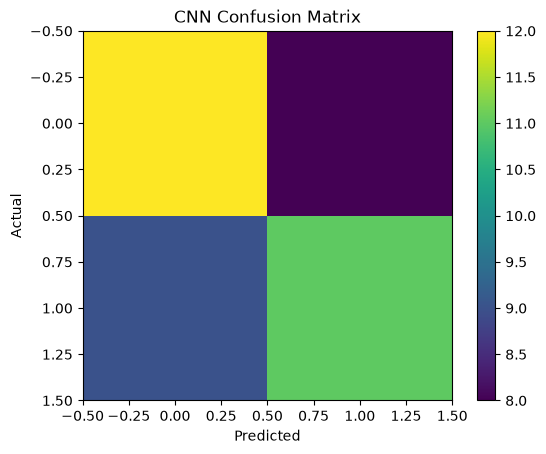

In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, cnn_pred)

print("Confusion Matrix:")
print(cm)

plt.imshow(cm)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


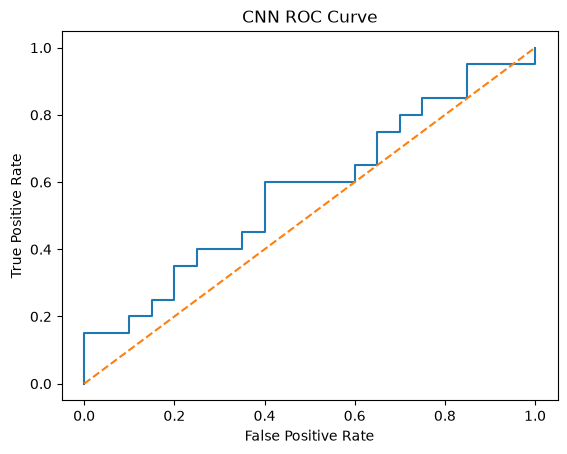

CNN ROC-AUC: 0.575


In [68]:
from sklearn.metrics import roc_curve, roc_auc_score


cnn_probability = best_cnn.predict(X_test).flatten()

fpr, tpr, thresholds = roc_curve(
    y_test,
    cnn_probability
)

auc = roc_auc_score(
    y_test,
    cnn_probability
)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN ROC Curve")

plt.show()

print("CNN ROC-AUC:", auc)

In [69]:
from sklearn.metrics import roc_auc_score

lr_probability = logistic_model.predict_proba(X_test_flat)[:, 1]

lr_auc = roc_auc_score(
    y_test,
    lr_probability
)

print("CNN ROC-AUC:", auc)
print("Logistic Regression ROC-AUC:", lr_auc)

CNN ROC-AUC: 0.575
Logistic Regression ROC-AUC: 0.5375


In [72]:
comparison["ROC-AUC"] = [
        auc,
        lr_auc
    ]

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,CNN,0.575,0.578947,0.55,0.564103,0.5750
1,Logistic Regression,0.525,0.520000,0.65,0.577778,0.5375
